Alunos: Eduardo Traunig, Erick Branquinho Machado

In [21]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

import shap
shap.initjs()

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Erick080/T1_ML/refs/heads/main/filtered_thyroid_data.csv')
df.head()

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [3]:
df_encoded = pd.get_dummies(df, columns=[
    'Gender', 'Hx Radiothreapy', 'Adenopathy',
    'Pathology', 'Focality', 'Risk',
    'T', 'N', 'M', 'Stage', 'Response', 'Recurred'
], drop_first=True)

df = df_encoded
df.head()


,Age,Gender_M,Hx Radiothreapy_Yes,Adenopathy_Extensive,Adenopathy_Left,Adenopathy_No,Adenopathy_Posterior,Adenopathy_Right,Pathology_Hurthel cell,Pathology_Micropapillary,...,N_N1b,M_M1,Stage_II,Stage_III,Stage_IVA,Stage_IVB,Response_Excellent,Response_Indeterminate,Response_Structural Incomplete,Recurred_Yes
0,27,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,34,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,30,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,62,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,62,False,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False


In [4]:
Y = df['Recurred_Yes']
X = df.drop(columns=['Recurred_Yes'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

Árvore de Decisão

In [ ]:
decision_tree = DecisionTreeClassifier()
#param_grid = {
#    'max_depth': [2, 3, 4, 5],
#    'min_samples_split': [2, 4, 6],
#    'min_samples_leaf': [1, 2, 3],
#    'criterion': ['gini', 'entropy']
#}
param_grid = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': list(range(2,6)),
    'min_samples_leaf': list(range(1,4)),
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(decision_tree, param_grid, cv=3, scoring='f1')
grid_search.fit(X_train, Y_train)

print(grid_search.best_params_)
print("F1-Score no GridSearch:")
print(f"{grid_search.best_score_:.4f}")

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 2}
F1-Score no GridSearch:
0.9112


In [ ]:
y_pred = grid_search.predict(X_test)

#print("Relatório de classificação (teste):")
#print(classification_report(Y_test, y_pred))
print('Accuracy:', accuracy_score(Y_test, y_pred))
print('F1:', f1_score(Y_test, y_pred, average='macro'))
print('Precision:', precision_score(Y_test, y_pred, average='macro'))
print('Recall:', recall_score(Y_test, y_pred, average='macro'))

Accuracy: 0.974025974025974
F1: 0.9637476459510358
Precision: 0.9833333333333334
Recall: 0.9473684210526316


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


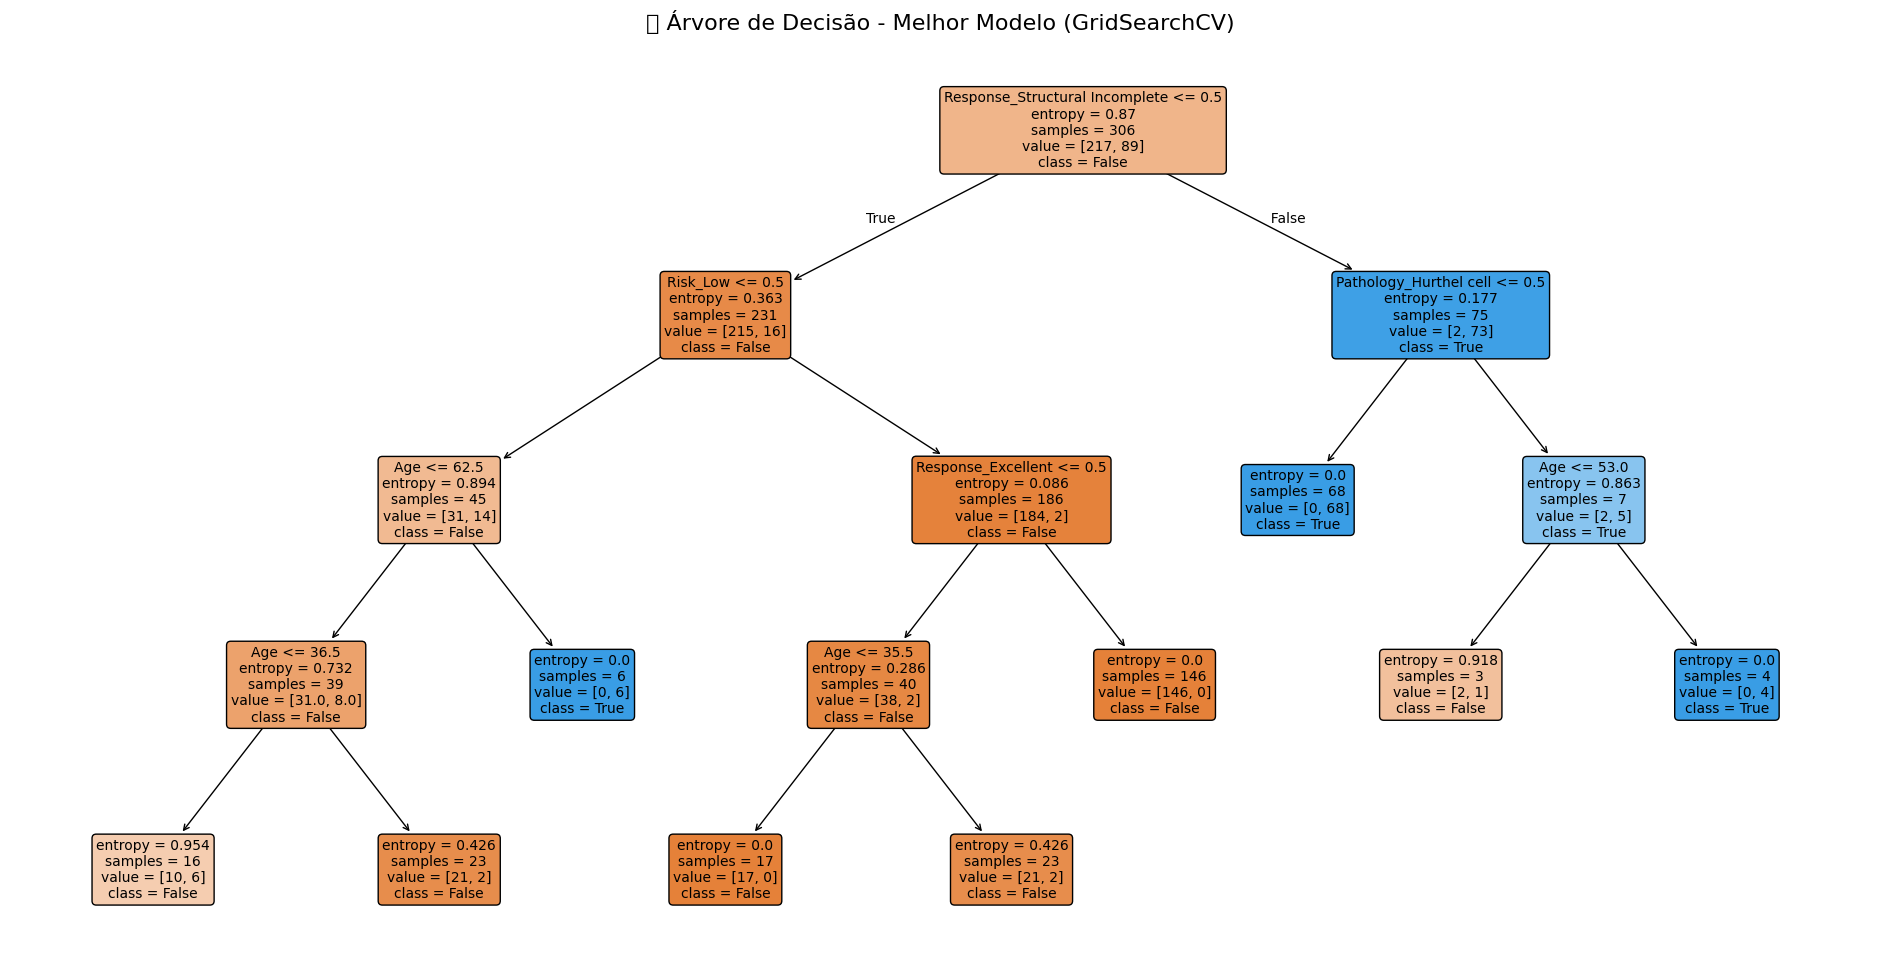

In [ ]:
# Plot da Arvore Gerada
best_tree = grid_search.best_estimator_

class_names = [str(cls) for cls in best_tree.classes_]

# Criar a figura
plt.figure(figsize=(24, 12))  # Tamanho ajustável conforme necessário
plot_tree(
    best_tree,
    filled=True,
    feature_names=X_train.columns,      # nomes das colunas codificadas
    class_names=class_names,            # agora as classes estão em string
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão - Melhor Modelo (GridSearchCV)", fontsize=16)
plt.show()

Naive Bayes

KNN


In [11]:
param_grid = {
      'n_neighbors': [7, 8, 9],
      'weights': ['uniform','distance'],
      'leaf_size': [1, 2, 3, 4, 5],
      'p': [1, 2, 3]
  }
# Grid search with cross-validation
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, n_jobs=-1)
grid_search.fit(X_train, Y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
best_score = grid_search.best_score_

Best parameters: {'leaf_size': 1, 'n_neighbors': 8, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.9051824431517715


In [9]:
y_pred = grid_search.predict(X_test)

#print("Relatório de classificação (teste):")
#print(classification_report(Y_test, y_pred))
print('Accuracy:', accuracy_score(Y_test, y_pred))
print('F1:', f1_score(Y_test, y_pred, average='macro'))
print('Precision:', precision_score(Y_test, y_pred, average='macro'))
print('Recall:', recall_score(Y_test, y_pred, average='macro'))

Accuracy: 0.8961038961038961
F1: 0.8422131147540983
Precision: 0.9068509615384616
Recall: 0.807168784029038


Configuracao do SHAP para gerar graficos informativos. O primeiro apresenta as features mais importantes na classificacao das instancias do dataset de treino

PermutationExplainer explainer: 78it [00:15,  1.85it/s]


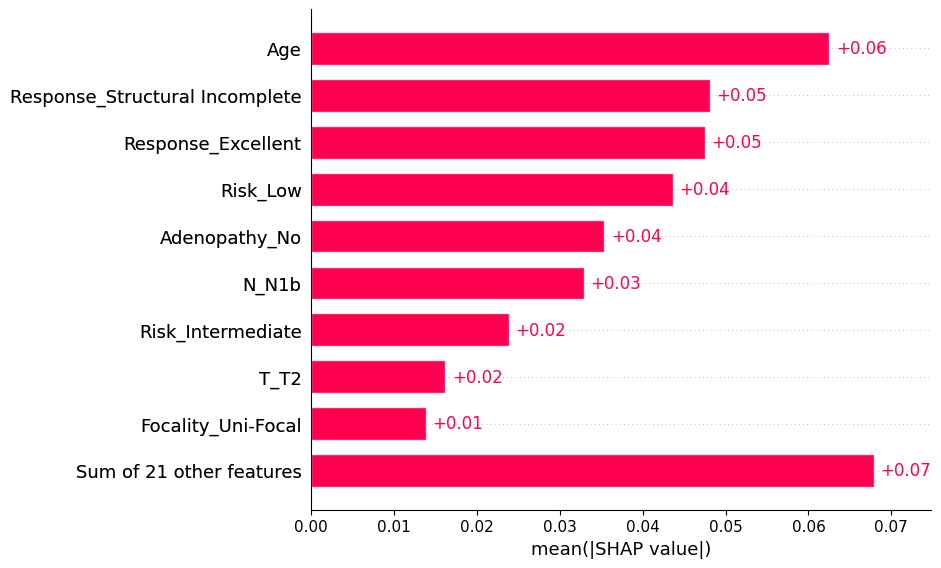

In [33]:
# Função de predição
def f(x):
    return grid_search.predict_proba(x)[:, 1]

# Conversão para float64
X_train_asfloat = X_train.astype(np.float64)
X_test_asfloat = X_test.astype(np.float64)

# Cria o explainer com background mais representativo
explainer = shap.Explainer(f, X_train_asfloat)

# Calcula valores SHAP
shap_values = explainer(X_test_asfloat.iloc[0:1000, :])

# Exibe gráfico de barras com as top features
shap.plots.bar(shap_values)

No grafico Beeswarm:
 - Cada ponto representa uma instancia
 - A cor representa o valor da feature, no caso de features booleanas, azul representa false e vermelho true
 - O valor SHAP positivo representa a influencia que a feature teve para classificar como *TRUE* a predicao da recorrencia de cancer de tireoide, e o negativo a predicao da nao recorrencia.

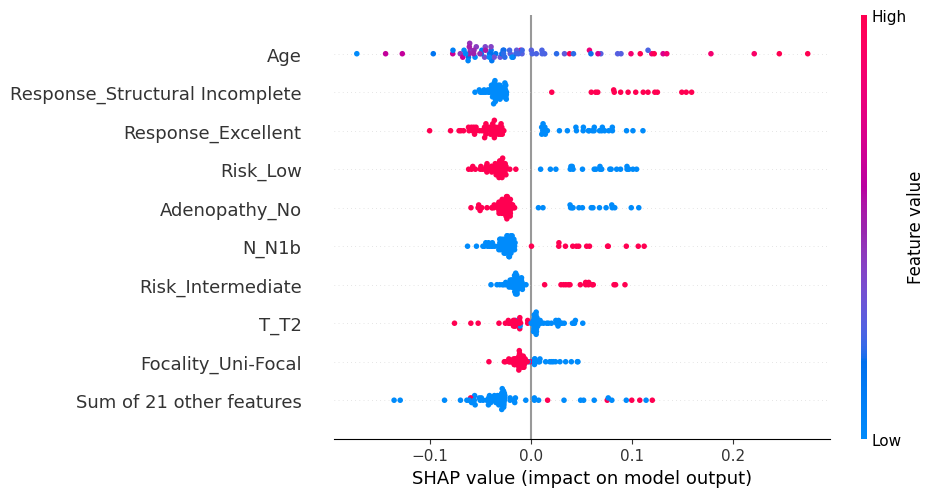

In [36]:
shap.plots.beeswarm(shap_values)